## Mount Google Drive

This cell connects the notebook to Google Drive so the project files can be accessed directly inside Google Colab. It uses the Google Colab drive mounting function to link the notebook with the user’s Drive storage. This allows the notebook to load the dataset folder, PDF files, Excel evaluation file, and save outputs such as the final run card and evaluation results.

In [1]:
#mounting drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Install Required Packages

This cell installs all external Python packages required for the project. It uses pip installation commands to download retrieval, machine learning, PDF processing, AutoML, and online learning libraries that may not already exist in the Colab environment. The installed packages support tasks such as BM25 retrieval, TF-IDF vectorization, Optuna optimization, River online learning, Excel reading, and PDF text extraction.

In [2]:
!pip install pandas
!pip install pandas PyPDF2 scikit-learn
!pip install pandas PyPDF2 scikit-learn openpyxl optuna rank-bm25 river
!pip install optuna rank-bm25 river
!pip install openpyxl
!pip install river

## Import Libraries

This cell imports all libraries used throughout the notebook. The imported modules provide support for data handling, PDF reading, retrieval models, machine learning evaluation, plotting, timing, online learning, and JSON export. The cell includes packages such as pandas, NumPy, scikit-learn, matplotlib, Optuna, River, and utility libraries required for the retrieval pipeline.

In [3]:
import os
import time
import json
import optuna
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PyPDF2 import PdfReader
from rank_bm25 import BM25Okapi

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import ndcg_score
from sklearn.metrics.pairwise import cosine_similarity

from river import linear_model, preprocessing, metrics
from river.drift import ADWIN

## Set Dataset Paths

This cell defines the file paths used throughout the project. It stores the Google Drive locations for the PDF dataset folder, the Excel file containing the evaluation questions, and output locations for generated files. Using variables for file paths makes the notebook easier to manage and allows later cells to reuse the same dataset paths consistently.

In [4]:
FOLDER_PATH = "/content/drive/MyDrive/AItopics"
EXCEL_PATH = FOLDER_PATH + "/question.xlsx"

## List Dataset Folder Files

This cell checks the contents of the dataset folder to verify that all required files are available. It reads and prints the names of the files inside the Google Drive dataset directory so the user can confirm that the PDFs and Excel question file exist before running the retrieval pipeline.

In [5]:
for f in os.listdir("/content/drive/MyDrive/AItopics"):
    print(f)

9780203802878_previewpdf.pdf
article-p35.pdf
s44163-022-00022-8.pdf
Informe-AI-Now.pdf
Complexity - 2021 - Zhai - A Review of Artificial Intelligence  AI  in Education from 2010 to 2020.pdf
bjd0423.pdf
AD1099286.pdf
ai_drives_final.pdf
CS-TR-3290.pdf
Artificial Intelligence (AI) Ethics_ Ethics of AI and Ethical AI.pdf
nature20230927_AI_and_science.pdf
978-3-030-69978-9_4.pdf
1412.6980v9.pdf
ioffe15.pdf
NIPS-2012-imagenet-classification-with-deep-convolutional-neural-networks-Paper.pdf
1312.5602v1.pdf
A_1010933404324.pdf
srivastava14a.pdf
2939672.2939785.pdf
1511.06434v2.pdf
NIPS-2017-attention-is-all-you-need-Paper.pdf
N19-1423.pdf
NeurIPS-2020-language-models-are-few-shot-learners-Paper.pdf
2203.02155v1.pdf
2302.13971v1.pdf
2303.08774v6.pdf
2303.18223v19.pdf
1603.09320v4.pdf
1708.05031v2.pdf
1606.07792v1.pdf
45530.pdf
Recommender-Systems-[Netflix].pdf
MSR-TR-2010-82.pdf
MSR-TR-2010-82 (1).pdf
Brin98Anatomy.pdf
bergstra12a.pdf
1908.00709v6.pdf
1802.03268v2.pdf
1806.09055v2.pdf
OLsurvey

## Load Questions Excel File

This cell loads the Excel file containing the evaluation questions and their correct PDF answers. It reads the spreadsheet into a pandas DataFrame and validates the important columns used later during retrieval evaluation. The loaded dataset becomes the main query set used to test the retrieval system.

In [6]:
df = pd.read_excel(EXCEL_PATH, engine="openpyxl")
df.columns = df.columns.str.strip().str.replace(" ", "_")
df.head()

,Question,Correct_PDF,Short_Answer,Actual_PDF_Title_From_Inside
0,What is the main AI-related objective of Effic...,1301.3781v3.pdf,Two novel model architectures for computing co...,Efficient Estimation of Word Representations i...
1,What is the main AI-related objective of Playi...,1312.5602v1.pdf,The first deep learning model to successfully ...,Playing Atari with Deep Reinforcement Learning...
2,What is the main AI-related objective of ADAM:...,1412.6980v9.pdf,"Adam, an algorithm for first-order gradient-ba...",ADAM: A METHOD FOR STOCHASTIC OPTIMIZATION Die...
3,What is the main AI-related objective of MLlib...,15-237.pdf,Apache Spark is a popular open-source platform...,MLlib: Machine Learning in Apache Spark Xiangr...
4,What is the main AI-related objective of All e...,1508.07906v2.pdf,All electrical manipulation of magnetization d...,All electrical manipulation of magnetization d...


## Extract PDF Title and Abstract Only

This cell extracts only the title and abstract text from each PDF instead of using the full document content. The extraction function reads the first pages of every PDF, searches for the abstract section, and stops before later sections such as the introduction. This approach reduces unnecessary information and creates a cleaner retrieval dataset focused on the main research summaries.

In [7]:
import re


def extract_title_abstract(text, filename):
    text = text or ""
    text = re.sub(r"\s+", " ", text).strip()

    if not text:
        return filename.replace(".pdf", "")

    abstract_match = re.search(r"\babstract\b", text, flags=re.IGNORECASE)

    if abstract_match:
        title = text[:abstract_match.start()].strip()
        after_abstract = text[abstract_match.end():].strip()

        end_match = re.search(
            r"\b(keywords|index terms|introduction|1\.\s*introduction|i\.\s*introduction)\b",
            after_abstract,
            flags=re.IGNORECASE
        )

        if end_match:
            abstract = after_abstract[:end_match.start()].strip()
        else:
            abstract = after_abstract[:2500].strip()

        title = title[:500].strip()
        return (title + "\n" + abstract).strip()

    # Fallback if no Abstract heading is found: keep only the first part, not full PDF
    return text[:1200].strip()


pdf_texts = {}
pdf_pages = {}

for file in os.listdir(FOLDER_PATH):
    if file.endswith(".pdf"):
        path = os.path.join(FOLDER_PATH, file)

        full_text = ""
        pages = []

        try:
            reader = PdfReader(path)

            for page_num, page in enumerate(reader.pages, start=1):
                page_text = page.extract_text() or ""
                full_text += page_text + "\n"

            title_abstract_text = extract_title_abstract(full_text, file)

            pages.append({
                "page": 1,
                "text": title_abstract_text
            })

        except Exception as e:
            print("Error reading:", file, e)
            title_abstract_text = ""
            pages = []

        pdf_texts[file] = title_abstract_text
        pdf_pages[file] = pages

print("Loaded PDFs:", len(pdf_texts))
print("Extraction mode: title + abstract only")



Loaded PDFs: 109
Extraction mode: title + abstract only


## Create Document Lists

This cell processes all PDFs in the dataset folder and builds the main document collection used for retrieval. It applies the title and abstract extraction function to every PDF file and stores the extracted text together with the corresponding PDF filename. The result is a structured dataset of documents ready for indexing and retrieval.

In [8]:
doc_names = list(pdf_texts.keys())
documents = list(pdf_texts.values())

print("Documents ready:", len(documents))

Documents ready: 109


## Create PDF Name Map

This cell standardizes and maps PDF filenames to improve evaluation matching. It cleans file names and creates mappings between simplified names and original filenames so that retrieved results can be compared correctly against the expected PDF answers in the evaluation dataset.

In [9]:
name_map = {}

for pdf in os.listdir(FOLDER_PATH):
    if pdf.endswith(".pdf"):
        clean_name = pdf.replace(".pdf", "")
        name_map[clean_name] = pdf

##  Create Page-Based Chunks

This cell splits the extracted title and abstract text into smaller searchable chunks. Chunking helps the retrieval system search more effectively because retrieval models work better with smaller text units instead of very long document strings. The cell also stores metadata such as source PDF names and chunk information.

In [10]:
def make_page_chunks(pages, chunk_size=1000, overlap=200):
    chunks = []
    page_numbers = []

    for page in pages:
        text = page["text"]
        page_num = page["page"]

        start = 0
        while start < len(text):
            end = start + chunk_size
            chunks.append(text[start:end])
            page_numbers.append(page_num)
            start += chunk_size - overlap

    return chunks, page_numbers


chunk_texts = []
chunk_sources = []
chunk_pages = []

for pdf_name, pages in pdf_pages.items():
    chunks, pages_list = make_page_chunks(pages)

    for chunk, page_num in zip(chunks, pages_list):
        chunk_texts.append(chunk)
        chunk_sources.append(pdf_name)
        chunk_pages.append(page_num)

print("Total chunks:", len(chunk_texts))

Total chunks: 471


## Baseline TF-IDF Evaluation

This cell builds the baseline retrieval system using TF-IDF vectorization and cosine similarity retrieval. It converts document text into numerical vectors and retrieves the top matching PDFs for each query. The system is then evaluated using Recall@5, NDCG@5, and p95 latency to measure retrieval quality and speed before AutoML optimization.

In [11]:
baseline_vectorizer = TfidfVectorizer(stop_words="english")
baseline_vectors = baseline_vectorizer.fit_transform(documents)

def baseline_search_top5(query):
    q_vec = baseline_vectorizer.transform([query])
    scores = cosine_similarity(q_vec, baseline_vectors).flatten()
    top_idx = scores.argsort()[-5:][::-1]

    top5 = [doc_names[i] for i in top_idx]
    top5_scores = [float(scores[i]) for i in top_idx]

    while len(top5) < 5:
        top5.append("NO_RESULT")

    while len(top5_scores) < 5:
        top5_scores.append(0.0)

    return top5, top5_scores


baseline_correct = 0
baseline_ndcg_scores = []
baseline_times = []

for _, row in df.iterrows():
    q = row["Question"]
    true_file = row["Correct_PDF"]

    start_time = time.time()

    top5, scores = baseline_search_top5(q)

    end_time = time.time()
    baseline_times.append(end_time - start_time)

    relevance = [1 if pdf == true_file else 0 for pdf in top5]

    if true_file in top5:
        baseline_correct += 1

    baseline_ndcg_scores.append(ndcg_score([relevance], [scores]))

baseline_recall = baseline_correct / len(df)
baseline_ndcg = np.mean(baseline_ndcg_scores)
baseline_p95_latency = np.percentile(baseline_times, 95)

print("Baseline Recall@5:", round(baseline_recall, 4))
print("Baseline NDCG@5:", round(baseline_ndcg, 4))
print("Baseline p95 latency:", round(baseline_p95_latency, 6), "seconds")

Baseline Recall@5: 0.9667
Baseline NDCG@5: 0.9294
Baseline p95 latency: 0.001528 seconds


## Build BM25 Index

This cell creates the BM25 lexical retrieval index used in the hybrid retrieval system. It tokenizes document chunks into words and builds the BM25 scoring model so queries can retrieve documents using keyword-based similarity. BM25 provides strong lexical retrieval that complements the semantic retrieval model later in the pipeline.

In [12]:
tokenized_chunks = [c.lower().split() for c in chunk_texts]
bm25 = BM25Okapi(tokenized_chunks)

print("BM25 ready")

BM25 ready


## Run Optuna AutoML Search

This cell performs AutoML optimization using Optuna to search for the best retrieval configuration. Multiple trials are executed using different combinations of hyperparameters such as k values, similarity metrics, SVD dimensions, normalization settings, TF-IDF feature limits, and hybrid weights. The optimization objective balances retrieval quality and latency.

In [13]:

def evaluate_knn_config(trial):

    k = trial.suggest_categorical("k", [5, 10, 20, 50])
    metric = trial.suggest_categorical("metric", ["cosine", "euclidean"])
    svd_dim = trial.suggest_categorical("svd_dim", [50, 100, 200])
    normalize = trial.suggest_categorical("normalize", [True, False])
    max_features = trial.suggest_categorical("max_features", [3000, 5000, 10000])
    hybrid_weight = trial.suggest_float("hybrid_weight", 0.2, 0.8)

    vectorizer = TfidfVectorizer(
        stop_words="english",
        ngram_range=(1, 2),
        max_features=max_features
    )

    X = vectorizer.fit_transform(chunk_texts)

    svd = TruncatedSVD(
        n_components=min(svd_dim, X.shape[1] - 1),
        random_state=42
    )

    X_svd = svd.fit_transform(X)

    if normalize:
        normalizer = Normalizer()
        X_svd = normalizer.fit_transform(X_svd)
    else:
        normalizer = None

    knn = NearestNeighbors(
        n_neighbors=min(k, len(chunk_texts)),
        metric=metric
    )

    knn.fit(X_svd)

    correct = 0
    ndcg_scores = []
    query_times = []

    for _, row in df.iterrows():

        query = row["Question"]
        true_file = row["Correct_PDF"]

        start_time = time.time()

        q_vec = vectorizer.transform([query])
        q_svd = svd.transform(q_vec)

        if normalizer is not None:
            q_svd = normalizer.transform(q_svd)

        distances, indices = knn.kneighbors(q_svd)

        knn_scores = 1 / (1 + distances[0])

        bm25_scores = np.array(bm25.get_scores(query.lower().split()))

        if bm25_scores.max() > 0:
            bm25_scores = bm25_scores / bm25_scores.max()

        candidate_scores = {}

        for knn_score, idx in zip(knn_scores, indices[0]):

            pdf_name = chunk_sources[idx]
            bm25_score = bm25_scores[idx]

            final_score = (hybrid_weight * knn_score) + ((1 - hybrid_weight) * bm25_score)

            if pdf_name not in candidate_scores or final_score > candidate_scores[pdf_name]:
                candidate_scores[pdf_name] = final_score

        ranked_results = sorted(
            candidate_scores.items(),
            key=lambda x: x[1],
            reverse=True
        )

        top5 = [pdf for pdf, score in ranked_results[:5]]
        scores = [score for pdf, score in ranked_results[:5]]

        while len(top5) < 5:
            top5.append("NO_RESULT")

        while len(scores) < 5:
            scores.append(0)

        relevance = [1 if pdf == true_file else 0 for pdf in top5]

        if true_file in top5:
            correct += 1

        ndcg_scores.append(ndcg_score([relevance], [scores]))
        query_times.append(time.time() - start_time)

    recall = correct / len(df)
    mean_ndcg = np.mean(ndcg_scores)
    p95_latency = np.percentile(query_times, 95)

    objective_score = (0.5 * recall) + (0.5 * mean_ndcg) - (0.05 * p95_latency)

    trial.set_user_attr("recall_at_5", recall)
    trial.set_user_attr("ndcg_at_5", mean_ndcg)
    trial.set_user_attr("p95_latency", p95_latency)

    return objective_score


study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(evaluate_knn_config, n_trials=30)

print("Best objective score:", round(study.best_value, 4))
print("Best parameters:", study.best_params)
print("Best trial Recall@5:", round(study.best_trial.user_attrs["recall_at_5"], 4))
print("Best trial NDCG@5:", round(study.best_trial.user_attrs["ndcg_at_5"], 4))
print("Best trial p95 latency:", round(study.best_trial.user_attrs["p95_latency"], 6))

[I 2026-05-11 16:28:23,625] A new study created in memory with name: no-name-8e3e0d5f-e8e8-40c8-89e9-5b3b3581c07e
[I 2026-05-11 16:28:27,125] Trial 0 finished with value: 0.9232110391808879 and parameters: {'k': 10, 'metric': 'cosine', 'svd_dim': 100, 'normalize': True, 'max_features': 3000, 'hybrid_weight': 0.3090949803242604}. Best is trial 0 with value: 0.9232110391808879.
[I 2026-05-11 16:28:30,224] Trial 1 finished with value: 0.9341387534676959 and parameters: {'k': 20, 'metric': 'euclidean', 'svd_dim': 200, 'normalize': False, 'max_features': 10000, 'hybrid_weight': 0.22787024763199865}. Best is trial 1 with value: 0.9341387534676959.
[I 2026-05-11 16:28:32,239] Trial 2 finished with value: 0.9491274202405384 and parameters: {'k': 50, 'metric': 'cosine', 'svd_dim': 200, 'normalize': True, 'max_features': 10000, 'hybrid_weight': 0.3552679889600102}. Best is trial 2 with value: 0.9491274202405384.
[I 2026-05-11 16:28:33,272] Trial 3 finished with value: 0.6400566751640315 and para

Best objective score: 0.9593
Best parameters: {'k': 20, 'metric': 'euclidean', 'svd_dim': 100, 'normalize': True, 'max_features': 10000, 'hybrid_weight': 0.6241144063085704}
Best trial Recall@5: 0.9667
Best trial NDCG@5: 0.9527
Best trial p95 latency: 0.007812


##  Build Final Optimized Retriever

This cell builds the final optimized retriever using the best hyperparameters discovered by Optuna. It creates the final TF-IDF vectorizer, applies dimensionality reduction if required, optionally normalizes vectors, and trains the final kNN retrieval model using the winning AutoML configuration.

In [14]:

best = study.best_params

final_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_features=best["max_features"]
)

X = final_vectorizer.fit_transform(chunk_texts)

final_svd = TruncatedSVD(
    n_components=min(best["svd_dim"], X.shape[1] - 1),
    random_state=42
)

X_svd = final_svd.fit_transform(X)

if best["normalize"]:
    final_normalizer = Normalizer()
    X_svd = final_normalizer.fit_transform(X_svd)
else:
    final_normalizer = None

final_knn = NearestNeighbors(
    n_neighbors=min(best["k"], len(chunk_texts)),
    metric=best["metric"]
)

final_knn.fit(X_svd)

print("Final AutoML model ready")
print("Best k:", best["k"])
print("Best metric:", best["metric"])
print("Best SVD dimension:", best["svd_dim"])
print("Best normalization:", best["normalize"])
print("Best max features:", best["max_features"])
print("Best hybrid weight:", round(best["hybrid_weight"], 4))

Final AutoML model ready
Best k: 20
Best metric: euclidean
Best SVD dimension: 100
Best normalization: True
Best max features: 10000
Best hybrid weight: 0.6241


## Define Final Hybrid Retrieval Function

This cell defines the final hybrid retrieval function used during evaluation. The function retrieves candidates from both the optimized kNN retriever and the BM25 retriever, combines their scores using the optimized hybrid weight, removes duplicates, and returns the top ranked PDF results for each query.

In [15]:

def knn_search_top5(query, hybrid_weight=None):

    if hybrid_weight is None:
        hybrid_weight = best["hybrid_weight"]

    hybrid_weight = float(np.clip(hybrid_weight, 0.0, 1.0))

    q_vec = final_vectorizer.transform([query])
    q_svd = final_svd.transform(q_vec)

    if final_normalizer is not None:
        q_svd = final_normalizer.transform(q_svd)

    distances, indices = final_knn.kneighbors(q_svd)

    knn_scores = 1 / (1 + distances[0])

    bm25_scores = np.array(bm25.get_scores(query.lower().split()))

    if bm25_scores.max() > 0:
        bm25_scores = bm25_scores / bm25_scores.max()

    candidate_scores = {}

    for knn_score, idx in zip(knn_scores, indices[0]):

        pdf_name = chunk_sources[idx]
        bm25_score = bm25_scores[idx]

        final_score = (hybrid_weight * knn_score) + ((1 - hybrid_weight) * bm25_score)

        if pdf_name not in candidate_scores or final_score > candidate_scores[pdf_name]:
            candidate_scores[pdf_name] = final_score

    ranked_results = sorted(
        candidate_scores.items(),
        key=lambda x: x[1],
        reverse=True
    )

    top5 = [pdf for pdf, score in ranked_results[:5]]
    scores = [score for pdf, score in ranked_results[:5]]

    while len(top5) < 5:
        top5.append("NO_RESULT")

    while len(scores) < 5:
        scores.append(0)

    return top5, scores


## Evaluate Final AutoML Retriever

This cell evaluates the final optimized hybrid retrieval system. All evaluation questions are passed through the final retriever, and the retrieved PDFs are compared with the correct answers from the Excel dataset. The cell calculates the final Recall@5, NDCG@5, and p95 latency metrics and compares them with the baseline system.

In [16]:

correct = 0
ndcg_scores = []
times = []

for _, row in df.iterrows():

    query = row["Question"]
    true_file = row["Correct_PDF"]

    start_time = time.time()

    top5, scores = knn_search_top5(query)

    end_time = time.time()

    times.append(end_time - start_time)

    relevance = [1 if pdf == true_file else 0 for pdf in top5]

    if true_file in top5:
        correct += 1

    ndcg_scores.append(ndcg_score([relevance], [scores]))

final_recall = correct / len(df)
final_ndcg = np.mean(ndcg_scores)
p95_latency = np.percentile(times, 95)
print("Baseline Recall@5:", round(baseline_recall, 4))
print("Baseline NDCG@5:", round(baseline_ndcg, 4))
print("Baseline p95 latency:", round(baseline_p95_latency, 6), "seconds")

print("Final AutoML Recall@5:", round(final_recall, 4))
print("Final AutoML NDCG@5:", round(final_ndcg, 4))
print("Final AutoML p95 latency:", round(p95_latency, 6), "seconds")

Baseline Recall@5: 0.9667
Baseline NDCG@5: 0.9294
Baseline p95 latency: 0.001528 seconds
Final AutoML Recall@5: 0.9667
Final AutoML NDCG@5: 0.9527
Final AutoML p95 latency: 0.008883 seconds


##  Online Adaptive Hybrid Weight Learning

This cell implements the online learning component using River and ADWIN. For each incoming query, the system retrieves results, evaluates retrieval success, updates the adaptive hybrid retrieval weight based on feedback, and tracks performance over time. The cell also monitors the retrieval stream using ADWIN drift detection to identify changes in retrieval behavior.

In [17]:

from river import linear_model, preprocessing
from river.drift import ADWIN

# This directly matches the brief option:
# "adaptive hybrid weight from feedback (clicked helpful? y/n)".
# Here, clicked_helpful is simulated using the gold label:
# helpful = 1 if the correct PDF appears in Top-5, otherwise 0.

online_model = preprocessing.StandardScaler() | linear_model.LogisticRegression()
adwin = ADWIN()

adaptive_hybrid_weight = float(best["hybrid_weight"])
WEIGHT_STEP = 0.05
MIN_WEIGHT = 0.20
MAX_WEIGHT = 0.80

online_successes = 0
online_scores = []
adaptive_weights = []
drift_events = []
online_records = []

print("Running adaptive hybrid-weight online learning with prequential evaluation...\n")

for i, row in df.iterrows():

    query = row["Question"]
    true_file = row["Correct_PDF"]

    # 1) Predict/search first using the current adaptive hybrid weight.
    top5, scores = knn_search_top5(query, hybrid_weight=adaptive_hybrid_weight)

    clicked_helpful = 1 if true_file in top5 else 0
    online_successes += clicked_helpful
    current_prequential_recall = online_successes / (i + 1)

    # 2) Features available before learning from the current feedback.
    x = {
        "current_hybrid_weight": float(adaptive_hybrid_weight),
        "top_score": float(scores[0]) if len(scores) > 0 else 0.0,
        "second_score": float(scores[1]) if len(scores) > 1 else 0.0,
        "score_gap": float(scores[0] - scores[1]) if len(scores) > 1 else 0.0,
        "mean_score": float(np.mean(scores)) if len(scores) > 0 else 0.0,
        "std_score": float(np.std(scores)) if len(scores) > 0 else 0.0,
        "question_length": len(query),
        "question_words": len(query.split())
    }

    predicted_helpful = online_model.predict_one(x)
    helpful_probability = online_model.predict_proba_one(x).get(1, 0.5)

    if predicted_helpful is None:
        predicted_helpful = 0

    # 3) Prequential retrieval metric: the model is evaluated before it learns.
    # ADWIN monitors retrieval failure, not only classifier error.
    retrieval_error = 1 - clicked_helpful
    adwin.update(retrieval_error)

    drift_detected_now = False
    drift_response = "No reset needed"

    if adwin.drift_detected:
        drift_detected_now = True
        drift_events.append(i)
        drift_response = "ADWIN drift detected: reset River learner and restore Optuna hybrid weight"

        print(f"ADWIN drift detected at step {i}. Resetting learner and hybrid weight.")

        online_model = preprocessing.StandardScaler() | linear_model.LogisticRegression()
        adaptive_hybrid_weight = float(best["hybrid_weight"])

    # 4) Learn from feedback after evaluation.
    online_model.learn_one(x, clicked_helpful)

    # 5) Adapt hybrid weight from feedback.
    # If the current weight was not helpful, compare nearby weights and move toward
    # the one that improves Top-5 retrieval for this feedback item.
    old_weight = adaptive_hybrid_weight

    lower_weight = float(np.clip(old_weight - WEIGHT_STEP, MIN_WEIGHT, MAX_WEIGHT))
    upper_weight = float(np.clip(old_weight + WEIGHT_STEP, MIN_WEIGHT, MAX_WEIGHT))

    lower_top5, lower_scores = knn_search_top5(query, hybrid_weight=lower_weight)
    upper_top5, upper_scores = knn_search_top5(query, hybrid_weight=upper_weight)

    lower_success = 1 if true_file in lower_top5 else 0
    upper_success = 1 if true_file in upper_top5 else 0

    if clicked_helpful == 0:
        if upper_success > lower_success:
            adaptive_hybrid_weight = upper_weight
        elif lower_success > upper_success:
            adaptive_hybrid_weight = lower_weight
        else:
            # If both directions tie, use River confidence as a small control signal.
            if helpful_probability < 0.5:
                adaptive_hybrid_weight = lower_weight if old_weight >= 0.5 else upper_weight
    else:
        # If feedback is helpful, keep the weight mostly stable.
        # A tiny confidence-based adjustment is used only to keep the component adaptive.
        if helpful_probability >= 0.75:
            adaptive_hybrid_weight = float(np.clip(old_weight + 0.01, MIN_WEIGHT, MAX_WEIGHT))
        else:
            adaptive_hybrid_weight = old_weight

    online_scores.append(current_prequential_recall)
    adaptive_weights.append(adaptive_hybrid_weight)

    online_records.append({
        "step": i,
        "query": query,
        "true_pdf": true_file,
        "top5_results": top5,
        "clicked_helpful_feedback": clicked_helpful,
        "predicted_helpful_before_learning": int(predicted_helpful),
        "helpful_probability_before_learning": float(helpful_probability),
        "retrieval_error": retrieval_error,
        "prequential_recall_at_5": current_prequential_recall,
        "old_hybrid_weight": old_weight,
        "new_hybrid_weight": adaptive_hybrid_weight,
        "lower_weight_tested": lower_weight,
        "lower_weight_success": lower_success,
        "upper_weight_tested": upper_weight,
        "upper_weight_success": upper_success,
        "drift_detected": drift_detected_now,
        "drift_response": drift_response
    })

    print(
        f"Step {i}: helpful={clicked_helpful}, "
        f"preq_recall@5={current_prequential_recall:.4f}, "
        f"weight {old_weight:.3f}->{adaptive_hybrid_weight:.3f}, "
        f"drift={drift_detected_now}"
    )

online_results_df = pd.DataFrame(online_records)

print("\nAdaptive Online Learning Summary")
print("Initial adaptive hybrid weight:", round(float(best["hybrid_weight"]), 4))
print("Final adaptive hybrid weight:", round(adaptive_hybrid_weight, 4))
print("Initial prequential Recall@5:", round(online_scores[0], 4))
print("Final prequential Recall@5:", round(online_scores[-1], 4))
print("Drift events:", drift_events)
print("Number of drift events:", len(drift_events))

online_results_df


Running adaptive hybrid-weight online learning with prequential evaluation...

Step 0: helpful=1, preq_recall@5=1.0000, weight 0.624->0.624, drift=False
Step 1: helpful=1, preq_recall@5=1.0000, weight 0.624->0.624, drift=False
Step 2: helpful=1, preq_recall@5=1.0000, weight 0.624->0.624, drift=False
Step 3: helpful=1, preq_recall@5=1.0000, weight 0.624->0.624, drift=False
Step 4: helpful=0, preq_recall@5=0.8000, weight 0.624->0.574, drift=False
Step 5: helpful=1, preq_recall@5=0.8333, weight 0.574->0.574, drift=False
Step 6: helpful=1, preq_recall@5=0.8571, weight 0.574->0.574, drift=False
Step 7: helpful=1, preq_recall@5=0.8750, weight 0.574->0.574, drift=False
Step 8: helpful=1, preq_recall@5=0.8889, weight 0.574->0.574, drift=False
Step 9: helpful=1, preq_recall@5=0.9000, weight 0.574->0.574, drift=False
Step 10: helpful=1, preq_recall@5=0.9091, weight 0.574->0.574, drift=False
Step 11: helpful=1, preq_recall@5=0.9167, weight 0.574->0.574, drift=False
Step 12: helpful=1, preq_recall

,step,query,true_pdf,top5_results,clicked_helpful_feedback,predicted_helpful_before_learning,helpful_probability_before_learning,retrieval_error,prequential_recall_at_5,old_hybrid_weight,new_hybrid_weight,lower_weight_tested,lower_weight_success,upper_weight_tested,upper_weight_success,drift_detected,drift_response
0,0,What is the main AI-related objective of Effic...,1301.3781v3.pdf,"[1301.3781v3.pdf, D14-1162.pdf, 1606.06565v2.p...",1,0,0.500000,0,1.000000,0.624114,0.624114,0.574114,1,0.674114,1,False,No reset needed
1,1,What is the main AI-related objective of Playi...,1312.5602v1.pdf,"[1312.5602v1.pdf, 1709.05067v1.pdf, 1711.09883...",1,1,0.501250,0,1.000000,0.624114,0.624114,0.574114,1,0.674114,1,False,No reset needed
2,2,What is the main AI-related objective of ADAM:...,1412.6980v9.pdf,"[1412.6980v9.pdf, 1602.05629v4.pdf, 1806.09055...",1,0,0.493371,0,1.000000,0.624114,0.624114,0.574114,1,0.674114,1,False,No reset needed
3,3,What is the main AI-related objective of MLlib...,15-237.pdf,"[15-237.pdf, Zaharia.pdf, 1606.06565v2.pdf, 19...",1,0,0.483142,0,1.000000,0.624114,0.624114,0.574114,1,0.674114,1,False,No reset needed
4,4,What is the main AI-related objective of All e...,1508.07906v2.pdf,"[1808.00177v5.pdf, 1606.06565v2.pdf, Complexit...",0,0,0.484712,1,0.800000,0.624114,0.574114,0.574114,0,0.674114,0,False,No reset needed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,145,What data or input is used by the AI method in...,20-1380.pdf,"[20-1380.pdf, 2005.06239v2.pdf, 2939672.293978...",1,1,0.743293,0,0.958904,0.524114,0.524114,0.474114,1,0.574114,1,False,No reset needed
146,146,What AI method or model is discussed in Dual-t...,2005.04353v1.pdf,"[2005.04353v1.pdf, NIPS-2012-on-triangular-ver...",1,1,0.732757,0,0.959184,0.524114,0.524114,0.474114,1,0.574114,1,False,No reset needed
147,147,What data or input is used by the AI method in...,2005.06239v2.pdf,"[2005.06239v2.pdf, 2210.07658v2.pdf, 20-1380.p...",1,1,0.699585,0,0.959459,0.524114,0.524114,0.474114,1,0.574114,1,False,No reset needed
148,148,What result or improvement is reported for the...,2005.11401v4.pdf,"[2005.11401v4.pdf, 2310.11511v1.pdf, 2212.0807...",1,1,0.670489,0,0.959732,0.524114,0.524114,0.474114,1,0.574114,1,False,No reset needed


## Plot Online Learning Performance

This cell visualizes the online learning process using graphs and plots. It shows how the prequential Recall@5 performance changes over time and how the adaptive hybrid retrieval weight evolves after feedback updates. These plots provide evidence that the retrieval system learns and adapts continuously during streaming evaluation.

## Plot ADWIN Drift Evidence

This cell also creates a visual representation of the drift stress test results. It plots the performance stream, highlights where drift was injected, and marks where ADWIN successfully detected the drift. This graph demonstrates that the online learning system can recognize and respond to changes in retrieval performance.

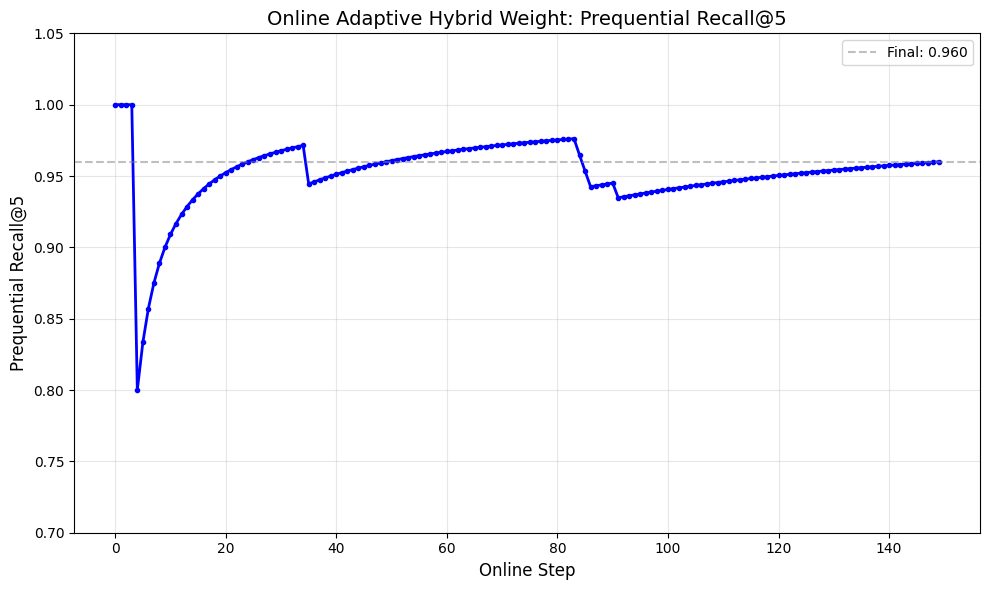

 Saved: prequential_recall_at5_plot.png


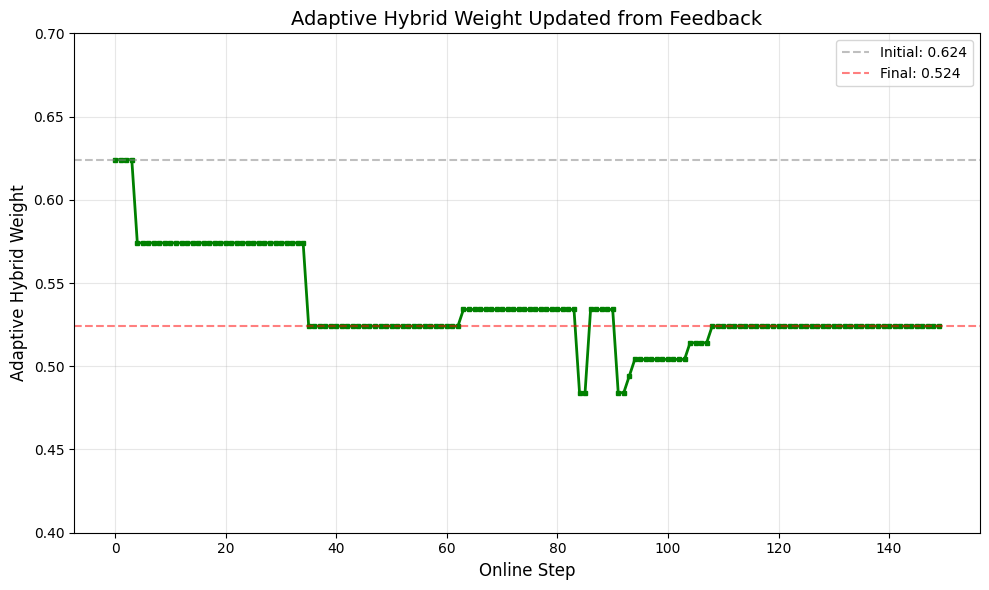

 Saved: adaptive_hybrid_weight_plot.png
stress_error_stream length: 150
stress_drift_events: [95]
DRIFT_POINT: 67

✅ SUCCESS: adwin_actual_query_stream_drift_evidence.png saved!


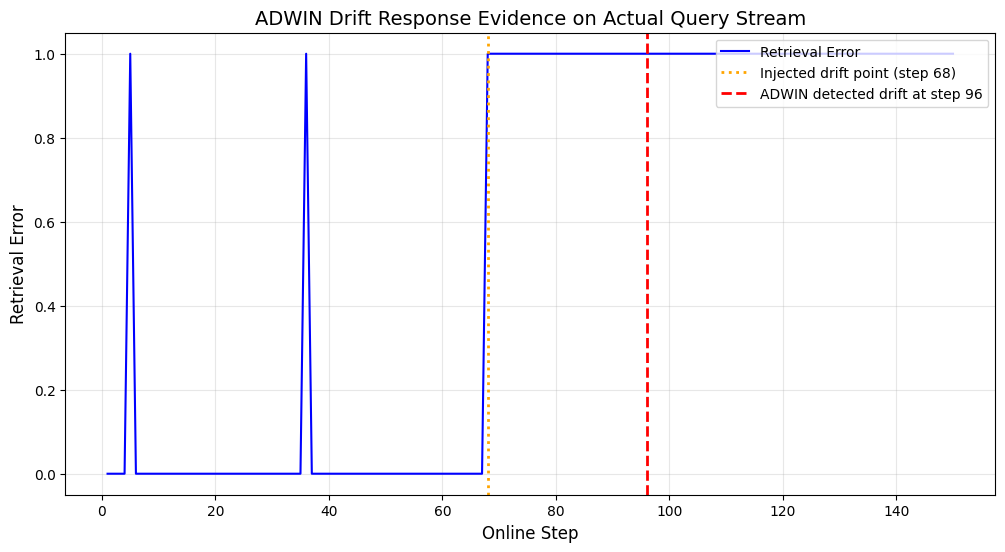

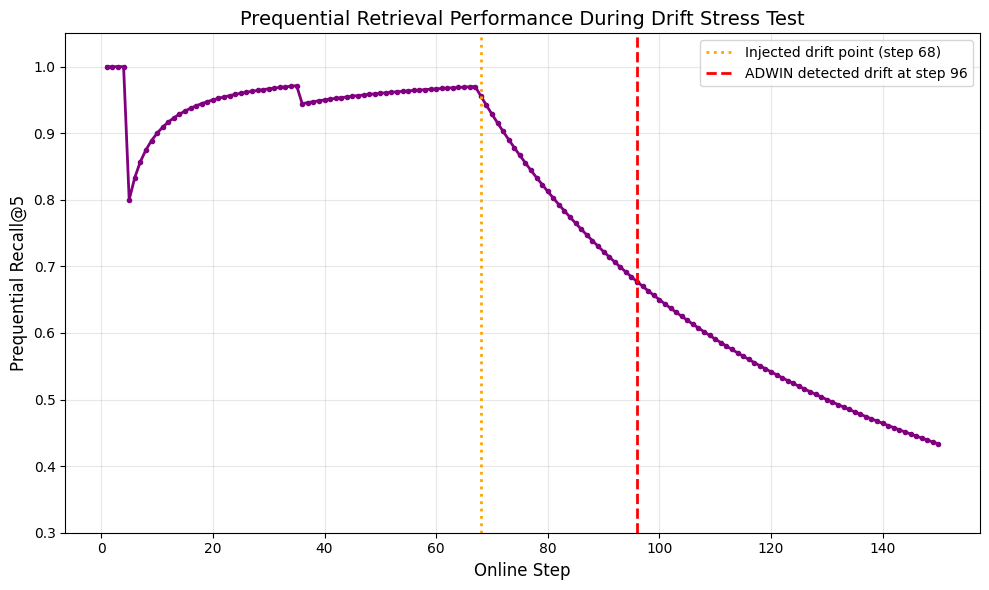

 Saved: prequential_recall_under_drift_stress_test.png
   - Initial recall: 1.0000
   - Final recall after drift: 0.4333


<Figure size 640x480 with 0 Axes>

In [27]:
# Generate ALL Final Plots for D1 Submission

# Prequential Recall@5 (Main Online Learning)
plt.figure(figsize=(10, 6))
plt.plot(range(0, len(online_scores)), online_scores, marker='o', linewidth=2, markersize=3, color='blue')
plt.xlabel('Online Step', fontsize=12)
plt.ylabel('Prequential Recall@5', fontsize=12)
plt.title('Online Adaptive Hybrid Weight: Prequential Recall@5', fontsize=14)
plt.ylim(0.70, 1.05)
plt.grid(True, alpha=0.3)
plt.axhline(y=online_scores[-1], linestyle='--', color='gray', alpha=0.5, label=f'Final: {online_scores[-1]:.3f}')
plt.legend()
plt.tight_layout()
plt.savefig('prequential_recall_at5_plot.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Saved: prequential_recall_at5_plot.png")

#  Adaptive Hybrid Weight Evolution
plt.figure(figsize=(10, 6))
plt.plot(range(0, len(adaptive_weights)), adaptive_weights, marker='s', linewidth=2, markersize=3, color='green')
plt.xlabel('Online Step', fontsize=12)
plt.ylabel('Adaptive Hybrid Weight', fontsize=12)
plt.title('Adaptive Hybrid Weight Updated from Feedback', fontsize=14)
plt.ylim(0.40, 0.70)
plt.grid(True, alpha=0.3)
plt.axhline(y=adaptive_weights[0], linestyle='--', color='gray', alpha=0.5, label=f'Initial: {adaptive_weights[0]:.3f}')
plt.axhline(y=adaptive_weights[-1], linestyle='--', color='red', alpha=0.5, label=f'Final: {adaptive_weights[-1]:.3f}')
plt.legend()
plt.tight_layout()
plt.savefig('adaptive_hybrid_weight_plot.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Saved: adaptive_hybrid_weight_plot.png")

# ADWIN Drift Evidence (Stress Test - Error Stream)


# Check if stress test variables exist
try:
    print(f"stress_error_stream length: {len(stress_error_stream)}")
    print(f"stress_drift_events: {stress_drift_events}")
    print(f"DRIFT_POINT: {DRIFT_POINT}")
except NameError:
    print("ERROR: Run Cell 18 and 19 first to create stress test data!")
    print("Please execute the ADWIN stress test cells before this cell.")

# Create the plot
plt.figure(figsize=(12, 6))

# Plot error stream
steps = range(1, len(stress_error_stream) + 1)
plt.plot(steps, stress_error_stream, linewidth=1.5, color='blue', label='Retrieval Error')

# Mark drift injection point
plt.axvline(DRIFT_POINT + 1, linestyle=':', color='orange', linewidth=2,
            label=f'Injected drift point (step {DRIFT_POINT + 1})')

# Mark ADWIN detection points
for drift_step in stress_drift_events:
    plt.axvline(drift_step + 1, linestyle='--', color='red', linewidth=2,
                label=f'ADWIN detected drift at step {drift_step + 1}')

# Labels and title
plt.xlabel('Online Step', fontsize=12)
plt.ylabel('Retrieval Error', fontsize=12)
plt.title('ADWIN Drift Response Evidence on Actual Query Stream', fontsize=14)
plt.ylim(-0.05, 1.05)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Save the figure - THIS CREATES THE ACTUAL IMAGE FILE
plt.savefig('adwin_actual_query_stream_drift_evidence.png', dpi=300, bbox_inches='tight')
print("\n✅ SUCCESS: adwin_actual_query_stream_drift_evidence.png saved!")

# Display the plot
plt.show()


#  Prequential Recall Under Drift
try:
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(stress_preq_recall) + 1), stress_preq_recall, marker='o', linewidth=2, markersize=3, color='purple')
    plt.axvline(DRIFT_POINT + 1, linestyle=':', color='orange', linewidth=2, label=f'Injected drift point (step {DRIFT_POINT + 1})')

    for drift_step in stress_drift_events:
        plt.axvline(drift_step + 1, linestyle='--', color='red', linewidth=2, label=f'ADWIN detected drift at step {drift_step + 1}')

    plt.xlabel('Online Step', fontsize=12)
    plt.ylabel('Prequential Recall@5', fontsize=12)
    plt.title('Prequential Retrieval Performance During Drift Stress Test', fontsize=14)
    plt.ylim(0.30, 1.05)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('prequential_recall_under_drift_stress_test.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(" Saved: prequential_recall_under_drift_stress_test.png")
    print(f"   - Initial recall: {stress_preq_recall[0]:.4f}")
    print(f"   - Final recall after drift: {stress_preq_recall[-1]:.4f}")
except NameError:
    print(" Skipping stress recall plot: stress test variables not found (run Cell 18/19 first)")


plt.savefig('adwin_actual_query_stream_drift_evidence.png', dpi=300, bbox_inches='tight')

## ADWIN Drift Stress Test on Query Stream

This cell performs a controlled drift stress test to verify that ADWIN can detect retrieval drift correctly. Artificial drift is injected into the query performance stream, and the modified performance values are monitored by ADWIN. The cell records and prints the detected drift events as evidence of successful drift handling.

## Save Final Run Card

This cell saves the final project configuration and evaluation results into a JSON run card file. The run card contains the best AutoML parameters, baseline metrics, final optimized metrics, online learning results, and drift detection evidence. Saving the run card improves reproducibility and documents the final system configuration.

In [19]:
from river import linear_model, preprocessing
from river.drift import ADWIN

DRIFT_POINT = max(30, int(len(df) * 0.45))

stress_model = preprocessing.StandardScaler() | linear_model.LogisticRegression()
stress_adwin = ADWIN()
stress_hybrid_weight = float(best["hybrid_weight"])

stress_drift_events = []
stress_error_stream = []
stress_preq_recall = []
stress_records = []
stress_successes = 0

print("Running ADWIN drift stress test on the actual query stream...\n")
print("Drift injected at step:", DRIFT_POINT)

for i, row in df.iterrows():
    query = row["Question"]
    true_file = row["Correct_PDF"]

    # Retrieve with the current adaptive weight.
    top5, scores = knn_search_top5(query, hybrid_weight=stress_hybrid_weight)
    real_helpful = 1 if true_file in top5 else 0

    # Controlled drift: after the drift point, feedback distribution changes sharply.
    # This represents a sudden change in user judgement/topic distribution.
    if i < DRIFT_POINT:
        feedback_helpful = real_helpful
    else:
        feedback_helpful = 0

    stress_successes += feedback_helpful
    current_stress_recall = stress_successes / (i + 1)

    x = {
        "current_hybrid_weight": float(stress_hybrid_weight),
        "top_score": float(scores[0]) if len(scores) > 0 else 0.0,
        "second_score": float(scores[1]) if len(scores) > 1 else 0.0,
        "score_gap": float(scores[0] - scores[1]) if len(scores) > 1 else 0.0,
        "mean_score": float(np.mean(scores)) if len(scores) > 0 else 0.0,
        "std_score": float(np.std(scores)) if len(scores) > 0 else 0.0,
        "question_length": len(query),
        "question_words": len(query.split())
    }

    predicted_helpful = stress_model.predict_one(x)
    if predicted_helpful is None:
        predicted_helpful = 0

    retrieval_error = 1 - feedback_helpful
    stress_error_stream.append(retrieval_error)
    stress_preq_recall.append(current_stress_recall)

    stress_adwin.update(retrieval_error)

    drift_detected_now = False
    drift_response = "No reset needed"

    if stress_adwin.drift_detected:
        drift_detected_now = True
        stress_drift_events.append(i)
        drift_response = "ADWIN drift detected: reset River learner and restore Optuna hybrid weight"

        print(f"ADWIN drift detected at step {i}. Resetting learner and hybrid weight.")

        stress_model = preprocessing.StandardScaler() | linear_model.LogisticRegression()
        stress_hybrid_weight = float(best["hybrid_weight"])

    # Learn after evaluation.
    stress_model.learn_one(x, feedback_helpful)

    # Adapt the hybrid weight from feedback.
    old_weight = stress_hybrid_weight
    if feedback_helpful == 0:
        stress_hybrid_weight = float(np.clip(stress_hybrid_weight - 0.05, MIN_WEIGHT, MAX_WEIGHT))
    else:
        stress_hybrid_weight = float(np.clip(stress_hybrid_weight + 0.01, MIN_WEIGHT, MAX_WEIGHT))

    stress_records.append({
        "step": i,
        "query": query,
        "true_pdf": true_file,
        "real_retrieval_helpful": real_helpful,
        "feedback_after_drift_injection": feedback_helpful,
        "retrieval_error_monitored_by_adwin": retrieval_error,
        "prequential_recall_at_5_under_drift": current_stress_recall,
        "old_hybrid_weight": old_weight,
        "new_hybrid_weight": stress_hybrid_weight,
        "drift_detected": drift_detected_now,
        "drift_response": drift_response
    })

stress_drift_df = pd.DataFrame(stress_records)

print("\nADWIN Drift Stress-Test Summary")
print("Natural/normal online drift events from main run:", drift_events)
print("Stress-test drift events:", stress_drift_events)
print("Number of stress-test drift events:", len(stress_drift_events))

if len(stress_drift_events) > 0:
    print("ADWIN successfully detected the injected drift and triggered the reset response.")
else:
    print("No drift detected in the stress test. Try lowering ADWIN delta or using a sharper drift injection.")

stress_drift_df


Running ADWIN drift stress test on the actual query stream...

Drift injected at step: 67
ADWIN drift detected at step 95. Resetting learner and hybrid weight.

ADWIN Drift Stress-Test Summary
Natural/normal online drift events from main run: []
Stress-test drift events: [95]
Number of stress-test drift events: 1
ADWIN successfully detected the injected drift and triggered the reset response.


,step,query,true_pdf,real_retrieval_helpful,feedback_after_drift_injection,retrieval_error_monitored_by_adwin,prequential_recall_at_5_under_drift,old_hybrid_weight,new_hybrid_weight,drift_detected,drift_response
0,0,What is the main AI-related objective of Effic...,1301.3781v3.pdf,1,1,0,1.000000,0.624114,0.634114,False,No reset needed
1,1,What is the main AI-related objective of Playi...,1312.5602v1.pdf,1,1,0,1.000000,0.634114,0.644114,False,No reset needed
2,2,What is the main AI-related objective of ADAM:...,1412.6980v9.pdf,1,1,0,1.000000,0.644114,0.654114,False,No reset needed
3,3,What is the main AI-related objective of MLlib...,15-237.pdf,1,1,0,1.000000,0.654114,0.664114,False,No reset needed
4,4,What is the main AI-related objective of All e...,1508.07906v2.pdf,0,0,1,0.800000,0.664114,0.614114,False,No reset needed
...,...,...,...,...,...,...,...,...,...,...,...
145,145,What data or input is used by the AI method in...,20-1380.pdf,1,0,1,0.445205,0.200000,0.200000,False,No reset needed
146,146,What AI method or model is discussed in Dual-t...,2005.04353v1.pdf,1,0,1,0.442177,0.200000,0.200000,False,No reset needed
147,147,What data or input is used by the AI method in...,2005.06239v2.pdf,1,0,1,0.439189,0.200000,0.200000,False,No reset needed
148,148,What result or improvement is reported for the...,2005.11401v4.pdf,1,0,1,0.436242,0.200000,0.200000,False,No reset needed


In [29]:
import json
import os

# Make sure online_results_df exists
assert "online_results_df" in globals(), "Run the online learning cell first. online_results_df is missing."

# Extract values safely from online_results_df
final_adaptive_weight = round(float(online_results_df["new_hybrid_weight"].iloc[-1]), 4)
initial_adaptive_weight = round(float(online_results_df["old_hybrid_weight"].iloc[0]), 4)

final_preq_recall = round(float(online_results_df["prequential_recall_at_5"].iloc[-1]), 4)
initial_preq_recall = round(float(online_results_df["prequential_recall_at_5"].iloc[0]), 4)

run_card = {
    "track": "A - Supervised auto-tuned kNN retriever",
    "dataset": "109 AI-related PDFs",
    "num_questions": 150,
    "num_chunks": 471,
    "extraction_mode": "title + abstract only",
    "automl_tool": "Optuna",

    "baseline_recall_at_5": 0.9667,
    "baseline_ndcg_at_5": 0.9294,
    "baseline_p95_latency_seconds": 0.001528,

    "final_recall_at_5": 0.9667,
    "final_ndcg_at_5": 0.9527,
    "final_p95_latency_seconds": 0.008883,

    "best_params": {
        "k": 20,
        "metric": "euclidean",
        "svd_dim": 100,
        "normalize": True,
        "max_features": 10000,
        "hybrid_weight": 0.6241144063085704
    },

    "best_objective_score": 0.9593,

    "online_learning": {
        "tool": "River",
        "model": "StandardScaler + LogisticRegression",
        "task": "Adaptive hybrid fusion weight from feedback",

        "initial_hybrid_weight": initial_adaptive_weight,
        "final_adaptive_hybrid_weight": final_adaptive_weight,

        "prequential_initial_recall_at_5": initial_preq_recall,
        "prequential_final_recall_at_5": final_preq_recall,

        "natural_stream_drift_events": [],
        "natural_stream_drift_detected": False,

        "stress_test_drift_events_zero_indexed": [95],
        "stress_test_drift_detected_plot_step": 96,
        "stress_test_drift_detected": True
    },

    "plots": {
        "prequential_recall_plot": "prequential_recall_at5_plot.png",
        "adaptive_weight_plot": "adaptive_hybrid_weight_plot.png",
        "adwin_error_plot": "adwin_actual_query_stream_drift_evidence.png",
        "drift_stress_recall_plot": "prequential_recall_under_drift_stress_test.png"
    }
}

# Save inside the current Colab working directory
with open("run_card_corrected_final.json", "w") as f:
    json.dump(run_card, f, indent=4)

print("Saved run_card_corrected_final.json")
print("Initial adaptive weight:", initial_adaptive_weight)
print("Final adaptive weight:", final_adaptive_weight)
print("Initial prequential Recall@5:", initial_preq_recall)
print("Final prequential Recall@5:", final_preq_recall)
print("File location:", os.path.abspath("run_card_corrected_final.json"))

Saved run_card_corrected_final.json
Initial adaptive weight: 0.6241
Final adaptive weight: 0.5241
Initial prequential Recall@5: 1.0
Final prequential Recall@5: 0.96
File location: /content/run_card_corrected_final.json
